In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_loss, load_plot, load_plot_all_runs

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Increase font sizes for better visibility
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [2]:
loader = ResultLoader("../results")
experiments = {
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "har": 0, "fixed_proto": 0, "init_emb": 0}),
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1}),

    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),
    "FedDPC": ("feddpc", {"lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01, "lambda_p": 1.0, "lambda_acl": 0.01}),
    "LG-FedAvg": ("lgfedavg", {}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "ProxyFL": ("proxyfl", {"mu": 1.0, "adj_type": "ring"}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    "Local": ("local", {}),
}
global_algos = ["FedAvg", "FedProx", "Scaffold", "FedDyn", "FedPLN", "FedProc", "FedFM", "MOON", "FedLSA"]
personalized_algos = ["FedPer", "FedRep", "FedProto", "FedALA", "FedTGP", "FedDPC", "LG-FedAvg", "FedKD", "FML", "ProxyFL", "FedSA", "Local"]

In [7]:
loader.algo_patterns["feddpc"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"

common_args = {"dataset": "cifar10", "partition": "dirichlet", "num_clients": 10, "epochs": 1, "batch_size": 64, "lr": 0.01, "alpha": 0.1, "n_class": 5, "times": 5}

experiments["FedDPC"] = ("feddpc", {"epochs": 1, "lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})

In [8]:
print("--- Personalized Algorithms Stats ---")
load_plot_all_runs(personalized_algos, experiments, common_args, loader, x_lim=200)
# load_plot_all_runs(['FedDPC'], experiments, common_args, loader, x_lim=200)

--- Personalized Algorithms Stats ---

Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
FedPer                    |  86.4047 ± 0.1055  |  85.9119 ± 0.1878  (5 runs)
FedRep                    |  86.5492 ± 0.1989  |  86.1223 ± 0.2918  (5 runs)
FedProto-Model            |  84.0729 ± 0.3274  |  83.6827 ± 0.3795  (5 runs)
FedProto-Proto            |  83.1263 ± 0.3549  |  82.7263 ± 0.3273  (5 runs)
FedALA                    |  86.6841 ± 0.3417  |  84.1543 ± 0.9095  (5 runs)
FedTGP-Model              |  84.6522 ± 0.2494  |  84.1863 ± 0.3217  (5 runs)
FedTGP-Proto              |  84.6080 ± 0.3464  |  83.0058 ± 0.5391  (5 runs)
FedDPC-Model              |  85.7603 ± 0.2608  |  85.2708 ± 0.2614  (5 runs)
FedDPC-Proto              |  85.9065 ± 0.2035  |  85.4371 ± 0.2475  (5 runs)
LG-FedAvg 

Figure saved to figures/split_test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
--------------------------------------------------------------------------------
Algorithm            |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
FedTGP               |      85.2384 |      83.3248 |      85.4714 |      83.4946
FedProto             |      84.5641 |      84.4612 |      84.7059 |      84.5941
FedDPC               |      86.2370 |      85.7024 |      86.2151 |      85.8489
--------------------------------------------------------------------------------


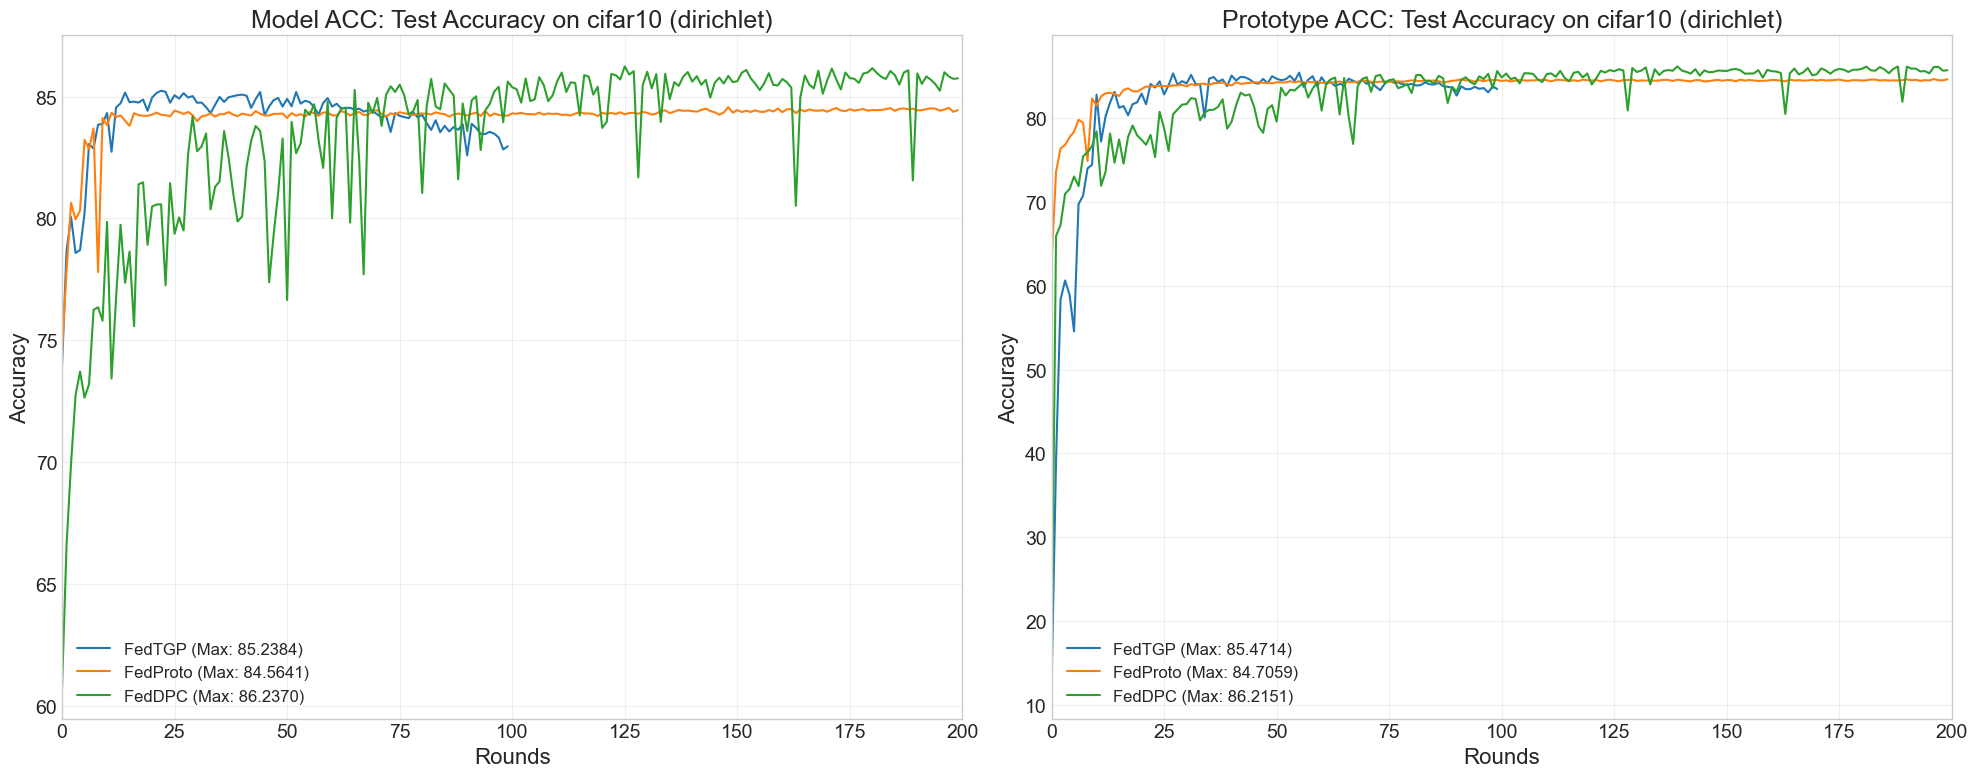

In [5]:
selected_group = personalized_algos.copy()
for algo in ['FedALA', 'FedPer', 'FedRep']:
    if algo in selected_group:
        selected_group.remove(algo)

selected_group = ['FedTGP', 'FedProto']
selected_group.extend(['FedDPC'])

load_plot(selected_group, experiments, common_args, loader, 200)

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedAvg               |         67.9500 |         67.7333
-----------------------------------------------------------------


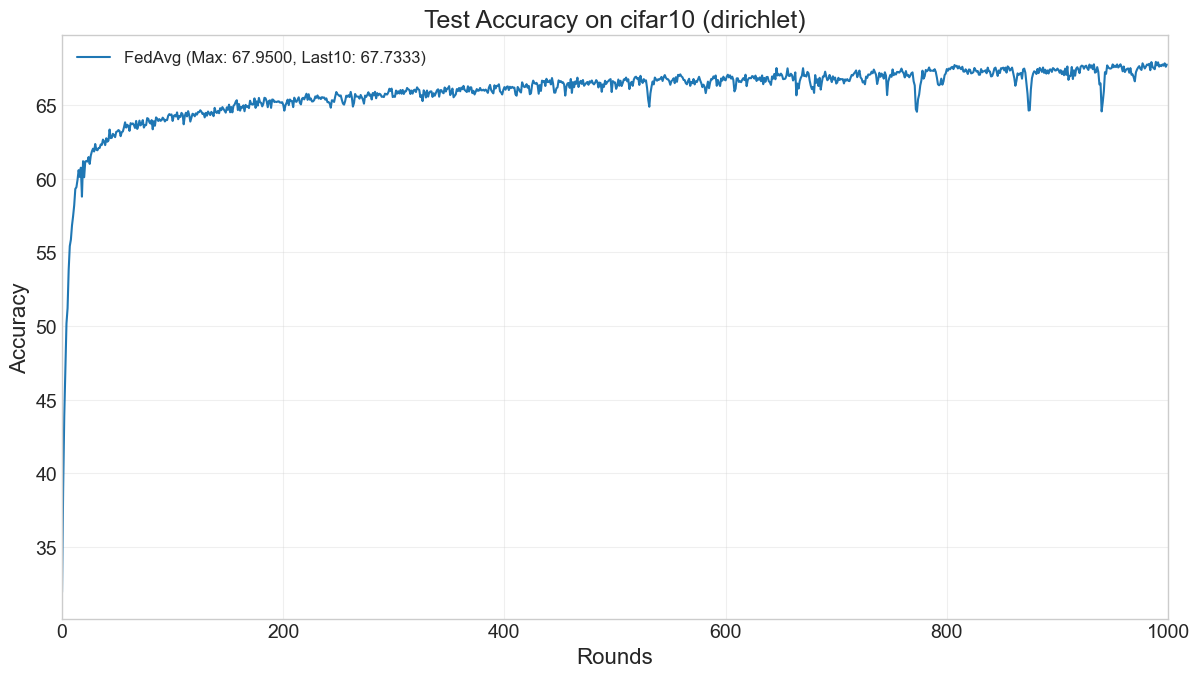

In [6]:
load_plot(["FedAvg"], experiments, common_args, loader, 1000)